In [1]:
import operator
from typing import Annotated, Literal, TypedDict

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command

In [2]:
class State(TypedDict):
    nlist: Annotated[list[str], operator.add]


Destination = Literal["b", "c", "__end__"]

In [3]:
class AppendingNode:
    def __init__(self, node_name: str) -> None:
        self.node_name = node_name

    def __call__(self, state: State) -> State:
        appended_string = self.node_name.lower()
        print(f"Appending {appended_string!r} to {state['nlist']}")
        return State(nlist=[appended_string])


class NodeFactory:
    @staticmethod
    def create_node(node_name: str) -> AppendingNode:
        return AppendingNode(node_name)

In [4]:
class InputRouter:
    def __init__(self, routes: dict[str, Destination]) -> None:
        self.routes = routes

    def __call__(self, state: State) -> Command[Destination]:
        selection = state["nlist"][-1].lower()
        destination = self.routes.get(selection, END)
        print(f"Routing {selection!r} to {destination!r}")
        return Command(update=State(nlist=[selection]), goto=destination)

In [5]:
builder = StateGraph(State)
factory = NodeFactory()
builder.add_node("a", InputRouter({"b": "b", "c": "c", "q": END}))
builder.add_node("b", factory.create_node("B"))
builder.add_node("c", factory.create_node("C"))

builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)

graph = builder.compile()

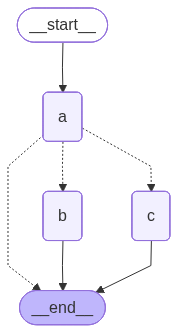

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
graph.invoke(State(nlist=["b"]))

Routing 'b' to 'b'
Appending 'b' to ['b', 'b']


{'nlist': ['b', 'b', 'b']}

In [8]:
graph.invoke(State(nlist=["c"]))

Routing 'c' to 'c'
Appending 'c' to ['c', 'c']


{'nlist': ['c', 'c', 'c']}

In [9]:
graph.invoke(State(nlist=["q"]))

Routing 'q' to '__end__'


{'nlist': ['q', 'q']}